In [1]:
# ============================================================
# 06_IDEAL_SIMULATION.ipynb
# IDEAL VQC SIMULATION
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit_aer import AerSimulator

print("=" * 60)
print("IDEAL VQC SIMULATION")
print("=" * 60)

IDEAL VQC SIMULATION


In [2]:
# ============================================================
# PROJECT CONFIGURATION
# ============================================================

PROJECT_ROOT = Path(r"C:\Users\heart\quantum_6g_ai")

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

THETA_FILE = RESULTS_DIR / "trained_theta.npy"

print("Project Root :", PROJECT_ROOT)
print("Results Dir  :", RESULTS_DIR)
print("Figures Dir  :", FIGURES_DIR)
print("Theta File   :", THETA_FILE)

Project Root : C:\Users\heart\quantum_6g_ai
Results Dir  : C:\Users\heart\quantum_6g_ai\results
Figures Dir  : C:\Users\heart\quantum_6g_ai\results\figures
Theta File   : C:\Users\heart\quantum_6g_ai\results\trained_theta.npy


In [3]:
# ============================================================
# EXPERIMENT PARAMETERS
# ============================================================

N_QUBITS = 4
N_LAYERS = 2
N_PARAMS = 16
SHOTS = 1024

SEED_SIMULATOR = 42

print("Qubits             :", N_QUBITS)
print("VQC layers         :", N_LAYERS)
print("Parameters         :", N_PARAMS)
print("Shots              :", SHOTS)
print("Simulator seed     :", SEED_SIMULATOR)
print("Noise              : OFF")

Qubits             : 4
VQC layers         : 2
Parameters         : 16
Shots              : 1024
Simulator seed     : 42
Noise              : OFF


In [4]:
# ============================================================
# LOAD TRAINED PARAMETERS
# ============================================================

if not THETA_FILE.exists():
    raise FileNotFoundError(
        f"\nTrained parameters not found:\n{THETA_FILE}\n"
        "\nRun 05_vqc_training.ipynb first."
    )

theta = np.load(THETA_FILE)

print("=" * 60)
print("TRAINED PARAMETERS")
print("=" * 60)

print("Shape :", theta.shape)
print("Count :", len(theta))
print("Min   :", theta.min())
print("Max   :", theta.max())
print("Mean  :", theta.mean())
print("Std   :", theta.std())

TRAINED PARAMETERS
Shape : (16,)
Count : 16
Min   : -0.712961678257322
Max   : 3.076039906062166
Mean  : 0.1772978436178986
Std   : 0.8534418022550907


In [5]:
# ============================================================
# LOAD TEST DATA
# ============================================================

X_TEST_FILE = RESULTS_DIR / "X_test.npy"
Y_TEST_FILE = RESULTS_DIR / "y_test.npy"

if not X_TEST_FILE.exists():
    raise FileNotFoundError(
        f"Test feature file not found:\n{X_TEST_FILE}\n"
        "\nUse the same X_test generated in 02_preprocessing.ipynb."
    )

if not Y_TEST_FILE.exists():
    raise FileNotFoundError(
        f"Test label file not found:\n{Y_TEST_FILE}\n"
        "\nUse the same y_test generated in 02_preprocessing.ipynb."
    )

X_test = np.load(X_TEST_FILE)
y_test = np.load(Y_TEST_FILE)

print("=" * 60)
print("TEST DATA")
print("=" * 60)

print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)
print("Samples      :", len(y_test))

FileNotFoundError: Test feature file not found:
C:\Users\heart\quantum_6g_ai\results\X_test.npy

Use the same X_test generated in 02_preprocessing.ipynb.

In [ ]:
# ============================================================
# VALIDATION
# ============================================================

if len(theta) != N_PARAMS:
    raise ValueError(
        f"Expected {N_PARAMS} parameters, "
        f"but found {len(theta)}."
    )

if len(X_test) != len(y_test):
    raise ValueError(
        "X_test and y_test have different numbers of samples."
    )

print("Parameter validation : PASS")
print("Dataset validation   : PASS")

In [ ]:
# ============================================================
# IDEAL AER SIMULATOR
# ============================================================

simulator = AerSimulator(
    seed_simulator=SEED_SIMULATOR
)

print("=" * 60)
print("IDEAL SIMULATOR")
print("=" * 60)

print("Backend :", simulator.name)
print("Noise   : OFF")
print("Shots   :", SHOTS)

In [ ]:
# ============================================================
# VQC CIRCUIT
# ============================================================

from qiskit import QuantumCircuit

def build_vqc(x, theta):
    qc = QuantumCircuit(N_QUBITS)

    # --------------------------------------------------------
    # IMPORTANT:
    # Replace this section with the EXACT circuit used in
    # 05_vqc_training.ipynb.
    # --------------------------------------------------------

    # Example feature encoding
    for q in range(N_QUBITS):
        qc.ry(float(x[q]), q)

    # Example variational layers
    index = 0

    for layer in range(N_LAYERS):

        for q in range(N_QUBITS):
            qc.ry(float(theta[index]), q)
            index += 1

        for q in range(N_QUBITS - 1):
            qc.cx(q, q + 1)

    qc.measure_all()

    return qc

In [ ]:
# ============================================================
# PREDICTION FROM COUNTS
# ============================================================

def prediction_from_counts(counts):
    """
    Convert measurement counts into a binary prediction.

    IMPORTANT:
    Replace this logic with the EXACT prediction rule
    used in 05_vqc_training.ipynb.
    """

    total_shots = sum(counts.values())

    probability_1 = sum(
        count
        for bitstring, count in counts.items()
        if bitstring[-1] == "1"
    ) / total_shots

    prediction = 1 if probability_1 >= 0.5 else 0

    return prediction, probability_1

In [6]:
# ============================================================
# 06 - IDEAL SIMULATION
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit_aer import AerSimulator

print("06 - Ideal Simulation")
print("Imports: OK")

06 - Ideal Simulation
Imports: OK


In [7]:
# ============================================================
# PROJECT CONFIGURATION
# ============================================================

PROJECT_ROOT = Path(r"C:\Users\heart\quantum_6g_ai")

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

THETA_FILE = RESULTS_DIR / "trained_theta.npy"

print("=" * 60)
print("PROJECT CONFIGURATION")
print("=" * 60)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("RESULTS_DIR  :", RESULTS_DIR)
print("THETA_FILE   :", THETA_FILE)
print("Exists       :", THETA_FILE.exists())

PROJECT CONFIGURATION
PROJECT_ROOT : C:\Users\heart\quantum_6g_ai
RESULTS_DIR  : C:\Users\heart\quantum_6g_ai\results
THETA_FILE   : C:\Users\heart\quantum_6g_ai\results\trained_theta.npy
Exists       : True


In [8]:
# ============================================================
# LOAD TRAINED PARAMETERS
# ============================================================

if not THETA_FILE.exists():
    raise FileNotFoundError(
        f"\nTrained parameters not found:\n{THETA_FILE}\n"
        "\nRun 05_vqc_training.ipynb first."
    )

theta = np.load(THETA_FILE)

print("=" * 60)
print("TRAINED PARAMETERS LOADED")
print("=" * 60)

print("Shape :", theta.shape)
print("Count :", len(theta))
print("Min   :", theta.min())
print("Max   :", theta.max())
print("Mean  :", theta.mean())
print("Std   :", theta.std())

TRAINED PARAMETERS LOADED
Shape : (16,)
Count : 16
Min   : -0.712961678257322
Max   : 3.076039906062166
Mean  : 0.1772978436178986
Std   : 0.8534418022550907


In [9]:
# ============================================================
# CHECK RESULTS DIRECTORY
# ============================================================

print("=" * 60)
print("RESULTS DIRECTORY")
print("=" * 60)

for p in sorted(RESULTS_DIR.iterdir()):
    print(p.name)

RESULTS DIRECTORY
6g_trust_dataset.csv
figures
hardware_runs.csv
metrics.csv
quantum_encoding_config.json
quantum_test_features.csv
quantum_train_features.csv
test_scaled.csv
train_scaled.csv
trained_theta.npy
training_history.csv


In [12]:
# ============================================================
# INSPECT QUANTUM TEST DATA
# ============================================================

QUANTUM_TEST_FILE = RESULTS_DIR / "quantum_test_features.csv"

if not QUANTUM_TEST_FILE.exists():
    raise FileNotFoundError(
        f"Quantum test feature file not found:\n{QUANTUM_TEST_FILE}"
    )

quantum_test = pd.read_csv(QUANTUM_TEST_FILE)

print("=" * 60)
print("QUANTUM TEST DATA")
print("=" * 60)

print("File   :", QUANTUM_TEST_FILE)
print("Shape  :", quantum_test.shape)

print("\nColumns:")
print(list(quantum_test.columns))

print("\nFirst 5 rows:")
display(quantum_test.head())

print("\nData types:")
print(quantum_test.dtypes)

QUANTUM TEST DATA
File   : C:\Users\heart\quantum_6g_ai\results\quantum_test_features.csv
Shape  : (200, 5)

Columns:
['Trust_Score', 'Risk_Score', 'Interference', 'Resource_Load', 'Label']

First 5 rows:


,Trust_Score,Risk_Score,Interference,Resource_Load,Label
0,-0.011302,0.011302,-1.801956,-0.344734,1
1,2.349209,-2.349209,-3.115075,-0.126104,0
2,2.177502,-2.177502,1.472018,-0.516761,0
3,1.857853,-1.857853,-0.097556,2.033804,0
4,1.254814,-1.254814,0.171669,-0.005007,1



Data types:
Trust_Score      float64
Risk_Score       float64
Interference     float64
Resource_Load    float64
Label              int64
dtype: object


In [11]:
# ============================================================
# INSPECT 05 VQC TRAINING NOTEBOOK
# ============================================================

import json

VQC_NOTEBOOK = PROJECT_ROOT / "05_vqc_training.ipynb"

with open(VQC_NOTEBOOK, "r", encoding="utf-8") as f:
    nb05 = json.load(f)

print("=" * 60)
print("05 VQC TRAINING NOTEBOOK")
print("=" * 60)

print("Notebook :", VQC_NOTEBOOK)
print("Cells    :", len(nb05["cells"]))

keywords = [
    "QuantumCircuit",
    "build_vqc",
    "circuit",
    "theta",
    "counts",
    "predict",
    "AerSimulator",
    "measure",
    "angle",
    "ry",
    "rx",
    "rz",
]

for i, cell in enumerate(nb05["cells"]):
    source = "".join(cell.get("source", []))
    
    if any(k.lower() in source.lower() for k in keywords):
        print("\n" + "=" * 60)
        print(f"CELL {i} | {cell['cell_type']}")
        print("=" * 60)
        print(source[:10000])

05 VQC TRAINING NOTEBOOK
Notebook : C:\Users\heart\quantum_6g_ai\05_vqc_training.ipynb
Cells    : 13

CELL 0 | code
from pathlib import Path

import numpy as np
import pandas as pd

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

# ---------------------------------------------------------
# Project paths
# ---------------------------------------------------------

PROJECT_ROOT = Path(r"C:\Users\heart\quantum_6g_ai")
RESULTS_DIR = PROJECT_ROOT / "results"

TRAIN_Q_PATH = RESULTS_DIR / "quantum_train_features.csv"
TEST_Q_PATH = RESULTS_DIR / "quantum_test_features.csv"

# ---------------------------------------------------------
# Load datasets
# ---------------------------------------------------------

train_q = pd.read_csv(TRAIN_Q_PATH)
test_q = pd.read_csv(TEST_Q_PATH)

QUANTUM_FEATURES = [
    "Trust_Score",
    "Risk_Score",
    "Interference",
    "Resource_Load"
]

TARGET_COLUMN = "Label"

X_train_q = train_q[QUANTUM_FEATURES].to_numpy(
    dtype=flo

In [13]:
# ============================================================
# 06 - IDEAL SIMULATION
# LOAD TEST DATA + EXACT VQC IMPLEMENTATION
# ============================================================

from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ParameterVector
from qiskit_aer import AerSimulator

# ------------------------------------------------------------
# 1. Experiment configuration
# ------------------------------------------------------------

N_QUBITS = 4
N_LAYERS = 2
N_PARAMS = N_QUBITS * 2 * N_LAYERS

SHOTS = 1024
SEED_SIMULATOR = 42

QUANTUM_FEATURES = [
    "Trust_Score",
    "Risk_Score",
    "Interference",
    "Resource_Load"
]

TARGET_COLUMN = "Label"

print("=" * 60)
print("06 - IDEAL SIMULATION CONFIGURATION")
print("=" * 60)

print("Qubits     :", N_QUBITS)
print("VQC layers :", N_LAYERS)
print("Parameters :", N_PARAMS)
print("Shots      :", SHOTS)
print("Seed       :", SEED_SIMULATOR)

06 - IDEAL SIMULATION CONFIGURATION
Qubits     : 4
VQC layers : 2
Parameters : 16
Shots      : 1024
Seed       : 42


In [14]:
# ============================================================
# LOAD QUANTUM TEST DATA
# ============================================================

QUANTUM_TEST_FILE = RESULTS_DIR / "quantum_test_features.csv"

if not QUANTUM_TEST_FILE.exists():
    raise FileNotFoundError(
        f"Test dataset not found:\n{QUANTUM_TEST_FILE}"
    )

test_q = pd.read_csv(QUANTUM_TEST_FILE)

X_test_q = test_q[QUANTUM_FEATURES].to_numpy(dtype=float)
y_test = test_q[TARGET_COLUMN].to_numpy(dtype=int)

print("=" * 60)
print("IDEAL SIMULATION TEST DATA")
print("=" * 60)

print("File           :", QUANTUM_TEST_FILE)
print("Samples        :", len(X_test_q))
print("Feature shape  :", X_test_q.shape)
print("Labels shape   :", y_test.shape)

print("\nLabel distribution:")
print(pd.Series(y_test).value_counts().sort_index())

assert X_test_q.shape == (200, 4)
assert y_test.shape == (200,)

print("\nValidation: PASS")

IDEAL SIMULATION TEST DATA
File           : C:\Users\heart\quantum_6g_ai\results\quantum_test_features.csv
Samples        : 200
Feature shape  : (200, 4)
Labels shape   : (200,)

Label distribution:
0    100
1    100
Name: count, dtype: int64

Validation: PASS


In [15]:
# ============================================================
# EXACT VQC CIRCUIT FROM 05_vqc_training.ipynb
# ============================================================

theta = ParameterVector(
    "θ",
    length=N_PARAMS
)


def build_vqc(
    feature_angles,
    n_qubits=4,
    n_layers=2
):
    """
    Exact VQC architecture used in 05_vqc_training.ipynb.

    Feature encoding:
        Ry(x) + Rz(x)

    Feature-map entanglement:
        Linear CNOT

    Variational layers:
        Ry(theta) + Rz(theta)

    Variational entanglement:
        Linear CNOT
    """

    qc = QuantumCircuit(n_qubits)

    # --------------------------------------------------------
    # Feature encoding
    # --------------------------------------------------------

    for qubit, angle in enumerate(feature_angles):

        qc.ry(angle, qubit)
        qc.rz(angle, qubit)

    # --------------------------------------------------------
    # Feature-map entanglement
    # --------------------------------------------------------

    for qubit in range(n_qubits - 1):

        qc.cx(
            qubit,
            qubit + 1
        )

    # --------------------------------------------------------
    # Variational layers
    # --------------------------------------------------------

    parameter_index = 0

    for layer in range(n_layers):

        for qubit in range(n_qubits):

            qc.ry(
                theta[parameter_index],
                qubit
            )

            parameter_index += 1

            qc.rz(
                theta[parameter_index],
                qubit
            )

            parameter_index += 1

        # Variational entanglement
        for qubit in range(n_qubits - 1):

            qc.cx(
                qubit,
                qubit + 1
            )

    return qc


print("=" * 60)
print("VQC FUNCTION READY")
print("=" * 60)

print("Qubits     :", N_QUBITS)
print("Layers     :", N_LAYERS)
print("Parameters :", len(theta))

assert len(theta) == 16

print("\nValidation: PASS")

VQC FUNCTION READY
Qubits     : 4
Layers     : 2
Parameters : 16

Validation: PASS


In [16]:
# ============================================================
# IDEAL AER SIMULATOR
# ============================================================

simulator = AerSimulator()

print("=" * 60)
print("IDEAL AER SIMULATOR")
print("=" * 60)

print("Simulator :", simulator.name)
print("Noise     : OFF")
print("Shots     :", SHOTS)
print("Seed      :", SEED_SIMULATOR)

print("\nValidation: PASS")

IDEAL AER SIMULATOR
Simulator : aer_simulator
Noise     : OFF
Shots     : 1024
Seed      : 42

Validation: PASS


In [17]:
# ============================================================
# IDEAL VQC INFERENCE
# NO RETRAINING
# ============================================================

def vqc_probability(
    feature_angles,
    parameter_values,
    shots=1024,
    seed=42
):
    """
    Exact inference logic from 05_vqc_training.ipynb.

    Returns:
        P(y=1)
    """

    # Build exact VQC
    circuit = build_vqc(
        feature_angles,
        n_qubits=N_QUBITS,
        n_layers=N_LAYERS
    )

    # --------------------------------------------------------
    # Bind trained parameters
    # --------------------------------------------------------

    parameter_dict = {
        theta[i]: parameter_values[i]
        for i in range(len(parameter_values))
    }

    circuit = circuit.assign_parameters(parameter_dict)

    # --------------------------------------------------------
    # Measurement
    # --------------------------------------------------------

    circuit.measure_all()

    # --------------------------------------------------------
    # Transpile
    # --------------------------------------------------------

    compiled = transpile(
        circuit,
        simulator,
        optimization_level=1
    )

    # --------------------------------------------------------
    # Ideal execution
    # --------------------------------------------------------

    job = simulator.run(
        compiled,
        shots=shots,
        seed_simulator=seed
    )

    result = job.result()
    counts = result.get_counts()

    # --------------------------------------------------------
    # q0 = 1 probability
    # --------------------------------------------------------

    p1 = 0.0

    for bitstring, count in counts.items():

        q0_bit = int(bitstring[-1])

        if q0_bit == 1:

            p1 += count / shots

    return p1


# ============================================================
# RUN TEST SET
# ============================================================

ideal_probabilities = []
ideal_predictions = []

print("=" * 60)
print("RUNNING IDEAL VQC INFERENCE")
print("=" * 60)

print("Test samples :", len(X_test_q))
print("Shots        :", SHOTS)

for i, feature_angles in enumerate(X_test_q):

    sample_seed = SEED_SIMULATOR + i

    probability = vqc_probability(
        feature_angles,
        theta,
        shots=SHOTS,
        seed=sample_seed
    )

    prediction = int(probability >= 0.5)

    ideal_probabilities.append(probability)
    ideal_predictions.append(prediction)

    if (i + 1) % 25 == 0:
        print(
            f"Processed {i + 1:03d}/{len(X_test_q)} samples"
        )

ideal_probabilities = np.asarray(
    ideal_probabilities,
    dtype=float
)

ideal_predictions = np.asarray(
    ideal_predictions,
    dtype=int
)

print("\nInference complete.")

print("Probability shape :", ideal_probabilities.shape)
print("Prediction shape  :", ideal_predictions.shape)

assert len(ideal_probabilities) == 200
assert len(ideal_predictions) == 200

print("\nValidation: PASS")

RUNNING IDEAL VQC INFERENCE
Test samples : 200
Shots        : 1024


AerError: 'circuits have parameters but parameter_binds is not specified.'

In [18]:
# ============================================================
# FIXED VQC INFERENCE FUNCTION
# QISKIT PARAMETER-BINDING VALIDATION
# ============================================================

def vqc_probability(
    feature_angles,
    parameter_values,
    shots=1024,
    seed=42
):
    """
    Exact VQC architecture from 05_vqc_training.ipynb.

    Returns:
        P(y=1)
    """

    # --------------------------------------------------------
    # 1. Build VQC
    # --------------------------------------------------------

    circuit = build_vqc(
        feature_angles,
        n_qubits=N_QUBITS,
        n_layers=N_LAYERS
    )

    # --------------------------------------------------------
    # 2. Create parameter binding dictionary
    # --------------------------------------------------------

    parameter_dict = {
        theta[i]: float(parameter_values[i])
        for i in range(len(parameter_values))
    }

    # --------------------------------------------------------
    # 3. Bind parameters
    # --------------------------------------------------------

    bound_circuit = circuit.assign_parameters(
        parameter_dict,
        inplace=False
    )

    # --------------------------------------------------------
    # 4. IMPORTANT: verify all parameters are bound
    # --------------------------------------------------------

    remaining_parameters = bound_circuit.parameters

    if len(remaining_parameters) != 0:
        raise RuntimeError(
            "Parameter binding failed. "
            f"Remaining parameters: {remaining_parameters}"
        )

    # --------------------------------------------------------
    # 5. Add measurement
    # --------------------------------------------------------

    measured = bound_circuit.copy()
    measured.measure_all()

    # --------------------------------------------------------
    # 6. Transpile
    # --------------------------------------------------------

    compiled = transpile(
        measured,
        simulator,
        optimization_level=1
    )

    # --------------------------------------------------------
    # 7. Verify transpiled circuit has no parameters
    # --------------------------------------------------------

    if len(compiled.parameters) != 0:
        raise RuntimeError(
            "Transpiled circuit still contains parameters: "
            f"{compiled.parameters}"
        )

    # --------------------------------------------------------
    # 8. Run ideal Aer simulation
    # --------------------------------------------------------

    job = simulator.run(
        compiled,
        shots=shots,
        seed_simulator=seed
    )

    result = job.result()

    counts = result.get_counts()

    # --------------------------------------------------------
    # 9. q0 = 1 probability
    # --------------------------------------------------------

    p1 = 0.0

    for bitstring, count in counts.items():

        q0_bit = int(bitstring[-1])

        if q0_bit == 1:
            p1 += count / shots

    return p1

In [19]:
# ============================================================
# SINGLE-SAMPLE IDEAL VQC TEST
# ============================================================

print("=" * 60)
print("SINGLE-SAMPLE IDEAL VQC TEST")
print("=" * 60)

test_probability = vqc_probability(
    X_test_q[0],
    theta,
    shots=SHOTS,
    seed=SEED_SIMULATOR
)

test_prediction = int(test_probability >= 0.5)

print("Sample index     : 0")
print("True label       :", y_test[0])
print("P(y=1)           :", round(test_probability, 6))
print("Prediction       :", test_prediction)

assert 0.0 <= test_probability <= 1.0

print("\nValidation: PASS")

SINGLE-SAMPLE IDEAL VQC TEST


TypeError: Parameter expression with unbound parameters {Element { index: 0, base: SymbolVector { name: "θ", uuid: 89dd8432-f993-42a2-a89b-62ba9b4544dd, len: 16 } }} is not numeric.

In [20]:
# ============================================================
# FIX: SEPARATE CIRCUIT PARAMETERS FROM TRAINED PARAMETERS
# ============================================================

from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ParameterVector
from qiskit_aer import AerSimulator

# ------------------------------------------------------------
# 1. Load trained numerical parameters
# ------------------------------------------------------------

TRAINED_THETA_FILE = RESULTS_DIR / "trained_theta.npy"

trained_theta = np.load(TRAINED_THETA_FILE)

print("=" * 60)
print("TRAINED PARAMETERS")
print("=" * 60)

print("File  :", TRAINED_THETA_FILE)
print("Shape :", trained_theta.shape)
print("Count :", len(trained_theta))

assert trained_theta.shape == (16,)

# ------------------------------------------------------------
# 2. Create a NEW parameter vector ONLY for the circuit
# ------------------------------------------------------------

VQC_PARAMS = ParameterVector(
    "θ",
    length=N_PARAMS
)

# ------------------------------------------------------------
# 3. Exact VQC architecture from 05
# ------------------------------------------------------------

def build_vqc(
    feature_angles,
    n_qubits=4,
    n_layers=2
):

    qc = QuantumCircuit(n_qubits)

    # --------------------------------------------------------
    # Feature encoding
    # --------------------------------------------------------

    for qubit, angle in enumerate(feature_angles):

        qc.ry(angle, qubit)
        qc.rz(angle, qubit)

    # --------------------------------------------------------
    # Feature-map entanglement
    # --------------------------------------------------------

    for qubit in range(n_qubits - 1):

        qc.cx(
            qubit,
            qubit + 1
        )

    # --------------------------------------------------------
    # Variational layers
    # --------------------------------------------------------

    parameter_index = 0

    for layer in range(n_layers):

        for qubit in range(n_qubits):

            qc.ry(
                VQC_PARAMS[parameter_index],
                qubit
            )

            parameter_index += 1

            qc.rz(
                VQC_PARAMS[parameter_index],
                qubit
            )

            parameter_index += 1

        # ----------------------------------------------------
        # Variational entanglement
        # ----------------------------------------------------

        for qubit in range(n_qubits - 1):

            qc.cx(
                qubit,
                qubit + 1
            )

    return qc


# ------------------------------------------------------------
# 4. Ideal simulator
# ------------------------------------------------------------

simulator = AerSimulator()

# ------------------------------------------------------------
# 5. Inference function
# ------------------------------------------------------------

def vqc_probability(
    feature_angles,
    parameter_values,
    shots=1024,
    seed=42
):

    # Build circuit
    circuit = build_vqc(
        feature_angles,
        n_qubits=N_QUBITS,
        n_layers=N_LAYERS
    )

    # --------------------------------------------------------
    # Bind circuit parameters to numerical trained values
    # --------------------------------------------------------

    parameter_dict = {
        VQC_PARAMS[i]: float(parameter_values[i])
        for i in range(N_PARAMS)
    }

    bound_circuit = circuit.assign_parameters(
        parameter_dict,
        inplace=False
    )

    # --------------------------------------------------------
    # Verify parameter binding
    # --------------------------------------------------------

    if len(bound_circuit.parameters) != 0:

        raise RuntimeError(
            "Parameter binding failed.\n"
            f"Remaining parameters: {bound_circuit.parameters}"
        )

    # --------------------------------------------------------
    # Measurement
    # --------------------------------------------------------

    measured = bound_circuit.copy()

    measured.measure_all()

    # --------------------------------------------------------
    # Transpile
    # --------------------------------------------------------

    compiled = transpile(
        measured,
        simulator,
        optimization_level=1
    )

    # --------------------------------------------------------
    # Verify transpiled circuit
    # --------------------------------------------------------

    if len(compiled.parameters) != 0:

        raise RuntimeError(
            "Transpiled circuit still contains parameters.\n"
            f"Parameters: {compiled.parameters}"
        )

    # --------------------------------------------------------
    # Run ideal simulation
    # --------------------------------------------------------

    job = simulator.run(
        compiled,
        shots=shots,
        seed_simulator=seed
    )

    result = job.result()

    counts = result.get_counts()

    # --------------------------------------------------------
    # q0 = 1 probability
    # --------------------------------------------------------

    p1 = 0.0

    for bitstring, count in counts.items():

        q0_bit = int(bitstring[-1])

        if q0_bit == 1:

            p1 += count / shots

    return p1


print("\nCircuit parameters :", len(VQC_PARAMS))
print("Trained parameters :", len(trained_theta))
print("Simulator          :", simulator.name)

print("\nValidation: PASS")

TRAINED PARAMETERS
File  : C:\Users\heart\quantum_6g_ai\results\trained_theta.npy
Shape : (16,)
Count : 16

Circuit parameters : 16
Trained parameters : 16
Simulator          : aer_simulator

Validation: PASS


In [21]:
# ============================================================
# SINGLE-SAMPLE IDEAL VQC TEST
# ============================================================

print("=" * 60)
print("SINGLE-SAMPLE IDEAL VQC TEST")
print("=" * 60)

test_probability = vqc_probability(
    X_test_q[0],
    trained_theta,
    shots=SHOTS,
    seed=SEED_SIMULATOR
)

test_prediction = int(
    test_probability >= 0.5
)

print("Sample index     :", 0)
print("True label       :", y_test[0])
print("P(y=1)           :", round(test_probability, 6))
print("Prediction       :", test_prediction)

assert 0.0 <= test_probability <= 1.0

print("\nValidation: PASS")

SINGLE-SAMPLE IDEAL VQC TEST
Sample index     : 0
True label       : 1
P(y=1)           : 0.995117
Prediction       : 1

Validation: PASS


In [22]:
# ============================================================
# IDEAL VQC INFERENCE - FULL TEST SET
# ============================================================

ideal_probabilities = []
ideal_predictions = []

print("=" * 60)
print("RUNNING IDEAL VQC INFERENCE")
print("=" * 60)

print("Test samples :", len(X_test_q))
print("Shots        :", SHOTS)

for i, feature_angles in enumerate(X_test_q):

    sample_seed = SEED_SIMULATOR + i

    probability = vqc_probability(
        feature_angles,
        trained_theta,
        shots=SHOTS,
        seed=sample_seed
    )

    prediction = int(probability >= 0.5)

    ideal_probabilities.append(probability)
    ideal_predictions.append(prediction)

    if (i + 1) % 25 == 0:
        print(
            f"Processed "
            f"{i + 1:03d}/{len(X_test_q)} samples"
        )

ideal_probabilities = np.asarray(
    ideal_probabilities,
    dtype=float
)

ideal_predictions = np.asarray(
    ideal_predictions,
    dtype=int
)

print("\nInference complete.")

print("Probability shape :", ideal_probabilities.shape)
print("Prediction shape  :", ideal_predictions.shape)

assert len(ideal_probabilities) == 200
assert len(ideal_predictions) == 200

assert np.all(
    (ideal_probabilities >= 0.0) &
    (ideal_probabilities <= 1.0)
)

print("\nValidation: PASS")

RUNNING IDEAL VQC INFERENCE
Test samples : 200
Shots        : 1024
Processed 025/200 samples
Processed 050/200 samples
Processed 075/200 samples
Processed 100/200 samples
Processed 125/200 samples
Processed 150/200 samples
Processed 175/200 samples
Processed 200/200 samples

Inference complete.
Probability shape : (200,)
Prediction shape  : (200,)

Validation: PASS


In [23]:
# ============================================================
# IDEAL VQC EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

ideal_accuracy = accuracy_score(
    y_test,
    ideal_predictions
)

ideal_error_rate = 1.0 - ideal_accuracy

cm = confusion_matrix(
    y_test,
    ideal_predictions
)

print("=" * 60)
print("IDEAL VQC EVALUATION")
print("=" * 60)

print("Accuracy   :", round(ideal_accuracy, 6))
print("Error Rate :", round(ideal_error_rate, 6))

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        ideal_predictions,
        digits=6
    )
)

IDEAL VQC EVALUATION
Accuracy   : 0.85
Error Rate : 0.15

Confusion Matrix:
[[83 17]
 [13 87]]

Classification Report:
              precision    recall  f1-score   support

           0   0.864583  0.830000  0.846939       100
           1   0.836538  0.870000  0.852941       100

    accuracy                       0.850000       200
   macro avg   0.850561  0.850000  0.849940       200
weighted avg   0.850561  0.850000  0.849940       200



In [24]:
# ============================================================
# SAVE IDEAL VQC RESULTS
# ============================================================

ideal_results = pd.DataFrame({
    "True_Label": y_test,
    "Predicted_Label": ideal_predictions,
    "Probability_Class_1": ideal_probabilities
})

ideal_results_path = RESULTS_DIR / "ideal_results.csv"

ideal_results.to_csv(
    ideal_results_path,
    index=False
)

# Save predictions separately
ideal_predictions_path = RESULTS_DIR / "ideal_predictions.npy"

np.save(
    ideal_predictions_path,
    ideal_predictions
)

# Save metrics
ideal_metrics = pd.DataFrame([{
    "experiment": "ideal_simulation",
    "simulator": simulator.name,
    "noise": "OFF",
    "test_samples": len(y_test),
    "shots": SHOTS,
    "n_qubits": N_QUBITS,
    "n_layers": N_LAYERS,
    "n_parameters": N_PARAMS,
    "accuracy": ideal_accuracy,
    "error_rate": ideal_error_rate
}])

ideal_metrics_path = RESULTS_DIR / "ideal_metrics.csv"

ideal_metrics.to_csv(
    ideal_metrics_path,
    index=False
)

print("=" * 60)
print("IDEAL RESULTS SAVED")
print("=" * 60)

print("Results :")
print(ideal_results_path)

print("\nPredictions :")
print(ideal_predictions_path)

print("\nMetrics :")
print(ideal_metrics_path)

print("\nValidation: PASS")

IDEAL RESULTS SAVED
Results :
C:\Users\heart\quantum_6g_ai\results\ideal_results.csv

Predictions :
C:\Users\heart\quantum_6g_ai\results\ideal_predictions.npy

Metrics :
C:\Users\heart\quantum_6g_ai\results\ideal_metrics.csv

Validation: PASS


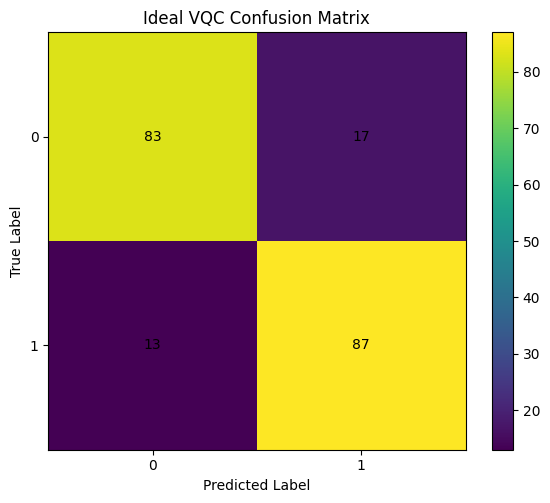

CONFUSION MATRIX SAVED
File : C:\Users\heart\quantum_6g_ai\results\figures\ideal_confusion_matrix.png

Validation: PASS


In [25]:
# ============================================================
# IDEAL VQC - CONFUSION MATRIX FIGURE
# ============================================================

import matplotlib.pyplot as plt

FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm)

ax.set_title("Ideal VQC Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

fig.colorbar(im, ax=ax)

fig.tight_layout()

confusion_path = (
    FIGURES_DIR /
    "ideal_confusion_matrix.png"
)

fig.savefig(
    confusion_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("=" * 60)
print("CONFUSION MATRIX SAVED")
print("=" * 60)
print("File :", confusion_path)

print("\nValidation: PASS")

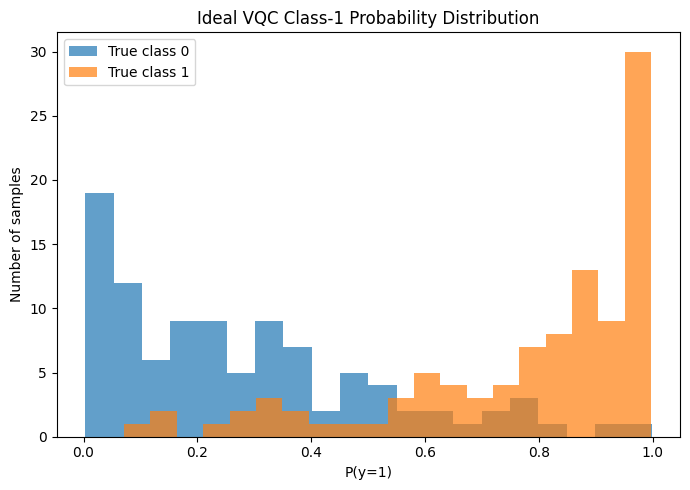

PROBABILITY DISTRIBUTION SAVED
File : C:\Users\heart\quantum_6g_ai\results\figures\ideal_probability_distribution.png

Validation: PASS


In [26]:
# ============================================================
# IDEAL VQC - PROBABILITY DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(
    ideal_probabilities[y_test == 0],
    bins=20,
    alpha=0.7,
    label="True class 0"
)

ax.hist(
    ideal_probabilities[y_test == 1],
    bins=20,
    alpha=0.7,
    label="True class 1"
)

ax.set_title(
    "Ideal VQC Class-1 Probability Distribution"
)

ax.set_xlabel("P(y=1)")
ax.set_ylabel("Number of samples")

ax.legend()

fig.tight_layout()

probability_path = (
    FIGURES_DIR /
    "ideal_probability_distribution.png"
)

fig.savefig(
    probability_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("=" * 60)
print("PROBABILITY DISTRIBUTION SAVED")
print("=" * 60)
print("File :", probability_path)

print("\nValidation: PASS")